In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import random

from utils.eval_metrics import (
    calculate_bis_metrics,
    get_age_group,
    create_results_dataframe,
    create_summary_by_age_group,
    save_evaluation_results,
)

# ============================================================================
# TRAINING CONFIGURATION
# ============================================================================

EPISODES = 10000
GAMMA = 0.69
STEPS_PER_EPISODE= 3600
FORCE_RETRAIN = True

INTEGRATION_DT_SECONDS = 1.0
DT = INTEGRATION_DT_SECONDS / 60.0
SIMULATION_STEP_SECONDS = 5.0
SIMULATION_STEP_SUBSTEPS = max(1, int(SIMULATION_STEP_SECONDS / INTEGRATION_DT_SECONDS))

# ============================================================================
# PK/PD PARAMETERS (Schnider Model)
# ============================================================================

V1 = 4.27
K10, K12, K13 = 0.119, 0.112, 0.042
K21, K31 = 0.055, 0.0033
KE0 = 0.17
E0, EMAX, EC50, HILL_PD = 97.4, 97.4, 3.4, 1.89
BIS_TARGET = 50.0
BIS_TARGET_RANGE = (40, 60)
ACTION_MIN, ACTION_MAX = 0.0, 6.0

# ============================================================================
# RL CONFIGURATION
# ============================================================================

ACTIONS = list(np.linspace(0.0, 6.0, 15))
BINS_PER_FEAT = 10
NUM_STATES = BINS_PER_FEAT**6
BIS_0, BIS_MAX = 97.4, 97.4

# ============================================================================
# EVALUATION CONFIGURATION
# ============================================================================

EVAL_SAMPLE_SIZE = 500
EVAL_EPISODE_LENGTHS = [300, 600, 1200, 3600]
RANDOM_SEED = 42

AGE_GROUPS = {
    "25-29": (25, 29),
    "30-45": (30, 45),
    "46-60": (46, 60),
    "60-80": (60, 80),
    "80+": (80, 120),
}

# ============================================================================
# PATHS
# ============================================================================

ARTIFACTS_DIR = Path("artifacts")
METRICS_DIR = Path("metrics")
DATA_PATH = Path("data/Patients Data.csv")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
DP_PATH = ARTIFACTS_DIR / "dp_bis_delta_bis_error_agent.npz"

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

def load_data(path):
    return pd.read_csv(path)


def preprocess_data(df):
    df = df.copy()

    def parse_age(x):
        try:
            parts = str(x).strip().split(" ")
            if len(parts) < 2:
                return 50
            low = int(parts[1])
            if len(parts) > 3:
                high = 100 if parts[3] == "older" else int(parts[3])
                return int(random.randrange(low, high))
            return int(low)
        except Exception:
            return 50

    if "AgeCategory" in df.columns:
        df.loc[:, "AgeCategory"] = df["AgeCategory"].apply(parse_age)
    return df


def schnider_model(age, weight, height, sex):
    sex = str(sex).lower()
    if sex == "male":
        lbm = 1.10 * weight - 128 * (weight**2) / (height**2)
    else:
        lbm = 1.07 * weight - 148 * (weight**2) / (height**2)

    V1_s = 4.27
    V2_s = 18.9 - 0.391 * (age - 53)

    k10_s = 0.443 + 0.0107 * (weight - 77) - 0.0159 * (lbm - 59) + 0.0062 * (height - 177)
    k12_s = 0.302 - 0.0056 * (age - 53)
    k13_s = 0.196
    k21_s = (1.29 - 0.024 * (age - 53)) / V2_s
    k31_s = 0.0035
    ke0_s = 0.456

    A = np.array(
        [
            [-(k10_s + k12_s + k13_s), k21_s, k31_s, 0],
            [k12_s, -k21_s, 0, 0],
            [k13_s, 0, -k31_s, 0],
            [ke0_s, 0, 0, -ke0_s],
        ],
        dtype=float,
    )
    B = np.array([[1 / V1_s], [0], [0], [0]], dtype=float)
    return {"A": A, "B": B}


def generate_schnider_dataset(df):
    params_list = []
    for _, row in df.iterrows():
        params = schnider_model(
            age=row["AgeCategory"],
            weight=row["WeightInKilograms"],
            height=row["HeightInMeters"],
            sex=row["Sex"],
        )
        params_list.append(params)

    params_df = pd.DataFrame(params_list)
    return pd.concat([df.reset_index(drop=True), params_df], axis=1)

# ============================================================================
# FUZZY STATE HELPER FUNCTIONS
# ============================================================================

def get_fuzzy_features(bis_error, delta_bis_error):
    error_scaled = np.clip(bis_error / 20.0, -1, 1)
    mu_error_neg = max(0, -error_scaled)
    mu_error_zero = max(0, 1.0 - abs(error_scaled))
    mu_error_pos = max(0, error_scaled)

    delta_scaled = np.clip(delta_bis_error / 20.0, -1, 1)
    mu_delta_neg = max(0, -delta_scaled)
    mu_delta_zero = max(0, 1.0 - abs(delta_scaled))
    mu_delta_pos = max(0, delta_scaled)

    return np.array([mu_error_neg, mu_error_zero, mu_error_pos, mu_delta_neg, mu_delta_zero, mu_delta_pos])


def state_to_idx(features):
    features = np.asarray(features)
    if features.shape != (6,):
        raise ValueError(f"features must be length-6 vector, got shape {features.shape}")

    bins = np.clip((features * (BINS_PER_FEAT - 1)), 0, BINS_PER_FEAT - 1).astype(int)
    idx = 0
    for b in bins:
        idx = idx * BINS_PER_FEAT + int(b)
    return idx


# ============================================================================
# DP EVALUATOR
# ============================================================================


class DPEvaluator:
    def __init__(self, policy, actions):
        self.policy = policy
        self.actions = np.asarray(actions)
        self.target = BIS_TARGET

    def simulate(self, patient_row, duration_seconds):
        duration_steps = max(1, int(duration_seconds / SIMULATION_STEP_SECONDS))
        A = np.asarray(patient_row["A"], dtype=float)
        B = np.asarray(patient_row["B"], dtype=float)
        x = np.zeros((4, 1), dtype=float)

        bis_log = []
        prev_error = 0.0
        last_action_idx = state_to_idx(get_fuzzy_features(0.0, 0.0))

        for step in range(duration_steps):
            ce = np.clip(float(x[3, 0]), 0.0, 10.0)
            ce_h = np.power(ce, HILL_PD)
            ec50_h = np.power(EC50, HILL_PD)

            if ce_h + ec50_h > 0:
                bis_ideal = E0 - EMAX * (ce_h / (ce_h + ec50_h))
            else:
                bis_ideal = E0

            measured_bis = np.clip(float(bis_ideal) + np.random.normal(0, 3), 0, 100)
            error = np.clip(float(measured_bis - self.target), -50.0, 50.0)
            derr = np.clip(float(error - prev_error), -30.0, 30.0)

            feat = get_fuzzy_features(error, derr)
            if step % 2 == 0:
                state_idx = state_to_idx(feat)
                last_action_idx = int(self.policy[state_idx])

            u = float(np.clip(self.actions[last_action_idx], ACTION_MIN, ACTION_MAX))
            for _ in range(SIMULATION_STEP_SUBSTEPS):
                x_dot = A @ x + B * u
                x = x + x_dot * DT
            x = np.clip(x, -10.0, 10.0)

            bis_log.append(float(measured_bis))
            prev_error = error

        return np.array(bis_log)

# TRAINING: Value Iteration

DYNAMIC PROGRAMMING: Value Iteration (BIS Error + deltaBIS)

Computing Transition Matrix (P) and Rewards (R)...
Transition matrix computed

Executing Value Iteration...
  Converged at iteration 49 (delta=0.00000083)

Extracting optimal policy...

Saving trained agent to artifacts\dp_bis_delta_bis_error_agent.npz...
Agent saved successfully!
Policy shape: (1000000,)
Value function shape: (1000000,)

Plotting BIS trajectory...


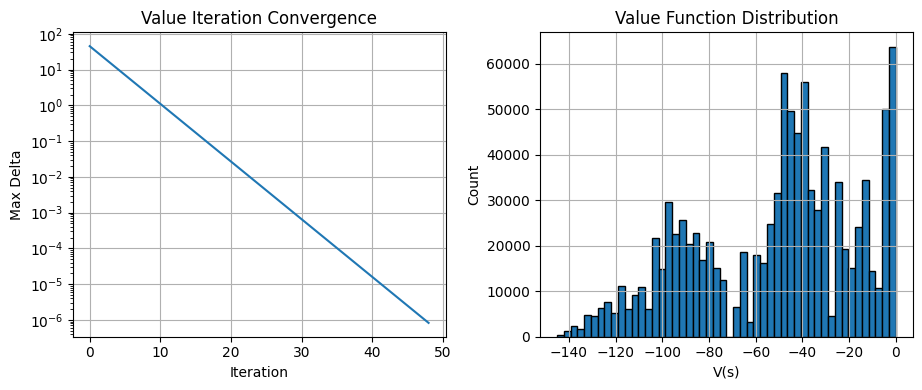

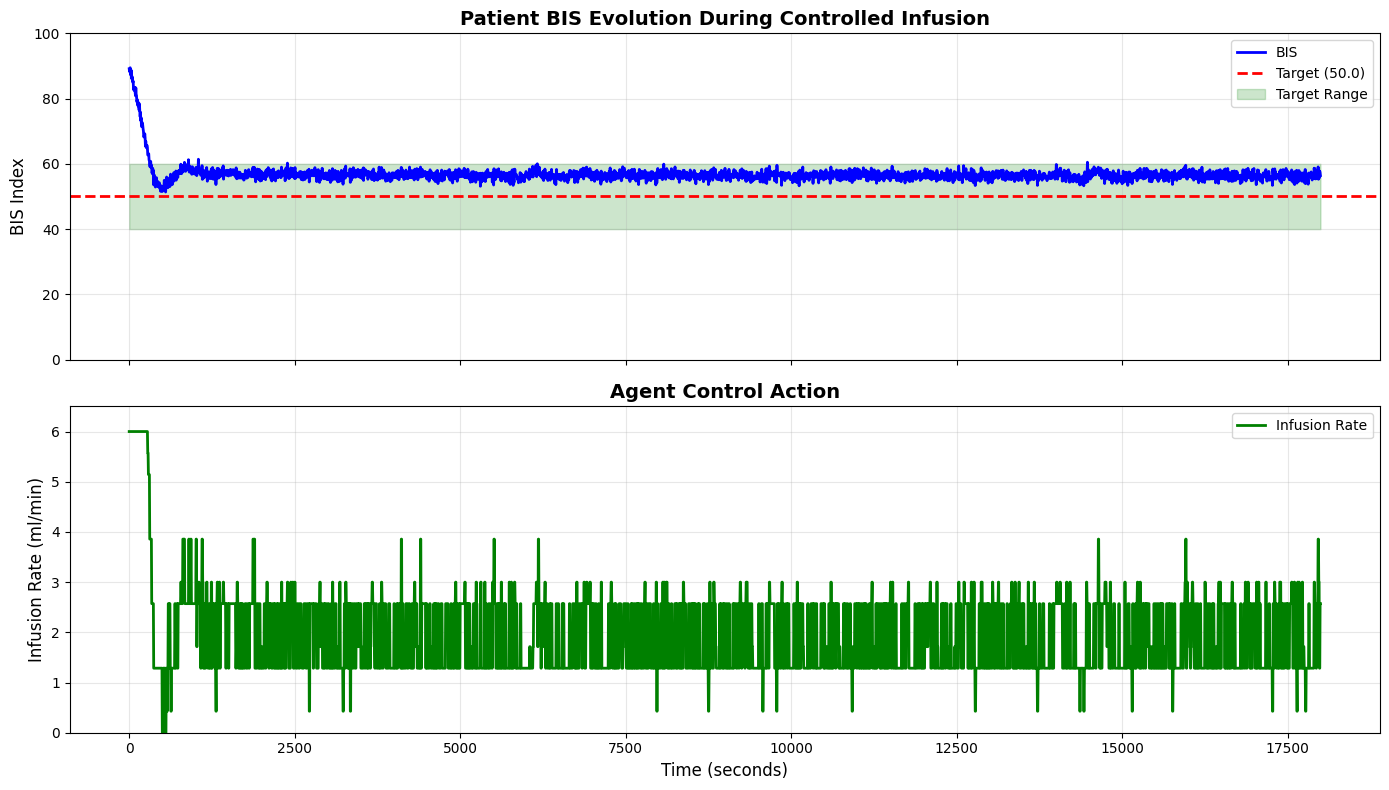


BIS trajectory plot saved to images/dp_bis_trajectory.png


In [3]:
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("=" * 70)
print("DYNAMIC PROGRAMMING: Value Iteration (BIS Error + deltaBIS)")
print("=" * 70)

loaded_V = None
if DP_PATH.exists() and not FORCE_RETRAIN:
    try:
        data = np.load(DP_PATH)
        loaded_V = data["V"]
        print(f"Loaded existing agent from {DP_PATH}")
    except Exception as e:
        print(f"Could not load existing agent: {e}")
elif DP_PATH.exists() and FORCE_RETRAIN:
    print(f"FORCE_RETRAIN=True: training from scratch")

print("\nComputing Transition Matrix (P) and Rewards (R)...")
P = np.zeros((NUM_STATES, len(ACTIONS)), dtype=int)
R = np.zeros((NUM_STATES, len(ACTIONS)))

for s in range(NUM_STATES):
    bins = np.array([
        s // (BINS_PER_FEAT**5),
        (s // (BINS_PER_FEAT**4)) % BINS_PER_FEAT,
        (s // (BINS_PER_FEAT**3)) % BINS_PER_FEAT,
        (s // (BINS_PER_FEAT**2)) % BINS_PER_FEAT,
        (s // BINS_PER_FEAT) % BINS_PER_FEAT,
        s % BINS_PER_FEAT,
    ], dtype=float)
    features = bins / (BINS_PER_FEAT - 1)

    bis_error = (features[2] - features[0]) * 30
    delta_bis_error = (features[5] - features[3]) * 30

    for a_idx, infusion in enumerate(ACTIONS):
        bis_error_next = bis_error - (infusion / max(ACTIONS)) * 15
        delta_bis_error_next = delta_bis_error - (infusion / max(ACTIONS)) * 10

        bis_error_next = np.clip(bis_error_next, -30, 30)
        delta_bis_error_next = np.clip(delta_bis_error_next, -30, 30)

        features_next = get_fuzzy_features(bis_error_next, delta_bis_error_next)
        s_next = state_to_idx(features_next)

        P[s, a_idx] = s_next
        R[s, a_idx] = -(abs(bis_error_next) + 0.5 * abs(delta_bis_error_next))

print("Transition matrix computed")

print("\nExecuting Value Iteration...")
if loaded_V is not None and loaded_V.shape == (NUM_STATES,):
    V = loaded_V.copy()
else:
    V = np.zeros(NUM_STATES)

THETA = 1e-6

iteration = 0
convergence_history = []
while iteration < EPISODES:
    V_old = V.copy()

    Q_vals = R + GAMMA * V[P]
    V = np.max(Q_vals, axis=1)

    max_delta = np.max(np.abs(V - V_old))
    convergence_history.append(max_delta)
    iteration += 1

    if iteration % 100 == 0:
        print(f"  Iteration {iteration}, max change: {max_delta:.8f}")

    if max_delta < THETA:
        print(f"  Converged at iteration {iteration} (delta={max_delta:.8f})")
        break

print("\nExtracting optimal policy...")
Q_vals = R + GAMMA * V[P]
policy = np.argmax(Q_vals, axis=1)

print(f"\nSaving trained agent to {DP_PATH}...")
np.savez(
    DP_PATH,
    V=V,
    policy=policy,
    P=P,
    R=R,
    actions=np.array(ACTIONS),
    gamma=GAMMA,
)
print("Agent saved successfully!")
print(f"Policy shape: {policy.shape}")
print(f"Value function shape: {V.shape}")

print("\nPlotting BIS trajectory...")
c0 = 2.0
x = np.array([[c0], [c0 * 0.3], [c0 * 0.1], [c0 * 0.5]], dtype=float)
bis_log = []
action_log = []
err_prev = 0.0
prev_state_idx = state_to_idx(get_fuzzy_features(0.0, 0.0))

for step in range(STEPS_PER_EPISODE):
    ce = np.clip(float(x[3, 0]), 0.0, 10.0)
    ce_h = np.power(ce, HILL_PD)
    ec50_h = np.power(EC50, HILL_PD)
    bis_ideal = E0 - EMAX * (ce_h / (ce_h + ec50_h)) if ce_h + ec50_h > 0 else E0
    measured_bis = np.clip(float(bis_ideal) + np.random.normal(0, 1), 0, 100)
    error = float(measured_bis - BIS_TARGET)
    derr = float(error - err_prev)
    
    if step % 2 == 0:
        feat = get_fuzzy_features(error, derr)
        state_idx = state_to_idx(feat)
        action_idx = int(policy[state_idx])
    
    u = float(np.clip(ACTIONS[action_idx], ACTION_MIN, ACTION_MAX))
    for _ in range(SIMULATION_STEP_SUBSTEPS):
        x_dot = np.array([
            [-(K10 + K12 + K13) * x[0, 0] + K21 * x[1, 0] + K31 * x[2, 0] + (u / V1)],
            [K12 * x[0, 0] - K21 * x[1, 0]],
            [K13 * x[0, 0] - K31 * x[2, 0]],
            [KE0 * (x[0, 0] - x[3, 0])],
        ])
        x = x + x_dot * DT
    x = np.clip(x, -10.0, 10.0)
    bis_log.append(measured_bis)
    action_log.append(u)
    err_prev = error

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(convergence_history)
plt.title('Value Iteration Convergence')
plt.xlabel('Iteration')
plt.ylabel('Max Delta')
plt.yscale('log')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.hist(V, bins=50, edgecolor='black')
plt.title('Value Function Distribution')
plt.xlabel('V(s)')
plt.ylabel('Count')
plt.grid(True)

plt.tight_layout()
plt.savefig('images/dp_training_plots.png', dpi=100)
plt.show()

time_steps = np.arange(len(bis_log)) * SIMULATION_STEP_SECONDS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(time_steps, bis_log, 'b-', linewidth=2, label='BIS')
ax1.axhline(y=BIS_TARGET, color='r', linestyle='--', linewidth=2, label=f'Target ({BIS_TARGET})')
ax1.fill_between(time_steps, BIS_TARGET_RANGE[0], BIS_TARGET_RANGE[1], alpha=0.2, color='green', label='Target Range')
ax1.set_ylabel('BIS Index', fontsize=12)
ax1.set_title('Patient BIS Evolution During Controlled Infusion', fontsize=14, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, 100])

ax2.plot(time_steps, action_log, 'g-', linewidth=2, label='Infusion Rate')
ax2.set_xlabel('Time (seconds)', fontsize=12)
ax2.set_ylabel('Infusion Rate (ml/min)', fontsize=12)
ax2.set_title('Agent Control Action', fontsize=14, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, max(ACTIONS) + 0.5])

plt.tight_layout()
plt.savefig('images/dp_bis_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nBIS trajectory plot saved to images/dp_bis_trajectory.png")

# EVALUATION: Test on Patient Population


1. Loading patient data from data\Patients Data.csv...
   Loaded 237630 patients

2. Sampling 500 patients...
   Sampled 500 patients

3. Generating Schnider PK/PD parameters...
   Generated parameters for 500 patients

4. Loading trained DP agent from artifacts\dp_bis_delta_bis_error_agent.npz...
   Loaded policy: shape (1000000,)

5. Evaluating policy at 4 episode lengths...
   Processing patient 50/500...
   Processing patient 100/500...
   Processing patient 150/500...
   Processing patient 200/500...
   Processing patient 250/500...
   Processing patient 300/500...
   Processing patient 350/500...
   Processing patient 400/500...
   Processing patient 450/500...
   Processing patient 500/500...

6. Saving evaluation results...
Saved results to metrics\dp_bis_delta_bis_error_results.json
Saved summary to metrics\dp_bis_delta_bis_error_summary.json

Evaluation complete!
  - Results: 500 patients
  - Age groups: 6
  - Episode lengths: [300, 600, 1200, 3600]

--- Summary Statistics (

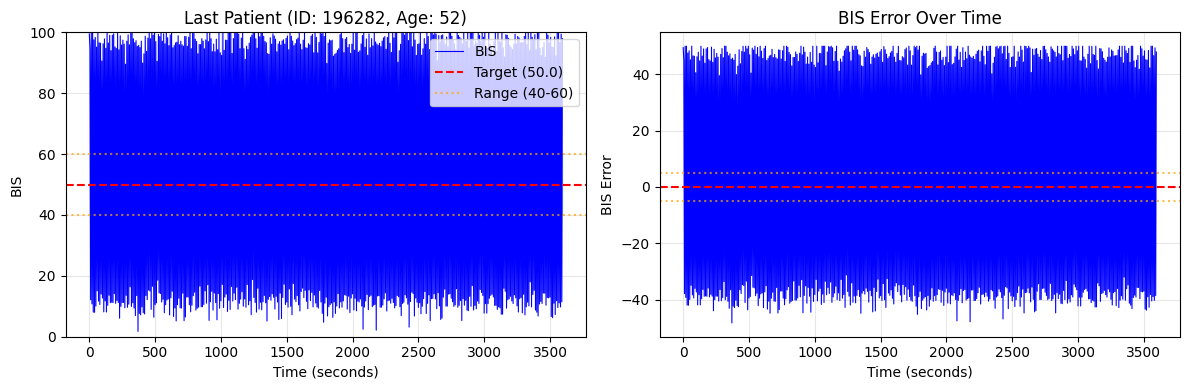


Last episode plot saved to images/dp_last_episode_plot.png


In [4]:
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"\n1. Loading patient data from {DATA_PATH}...")
df = load_data(DATA_PATH)
df = preprocess_data(df)
print(f"   Loaded {len(df)} patients")

print(f"\n2. Sampling {EVAL_SAMPLE_SIZE} patients...")
sample_df = df.sample(n=min(EVAL_SAMPLE_SIZE, len(df)), random_state=RANDOM_SEED)
print(f"   Sampled {len(sample_df)} patients")

print("\n3. Generating Schnider PK/PD parameters...")
eval_df = generate_schnider_dataset(sample_df)
print(f"   Generated parameters for {len(eval_df)} patients")

print(f"\n4. Loading trained DP agent from {DP_PATH}...")
dp_data = np.load(DP_PATH)
policy_eval = dp_data["policy"]
actions_eval = dp_data["actions"]
print(f"   Loaded policy: shape {policy_eval.shape}")

evaluator = DPEvaluator(policy_eval, actions_eval)

print(f"\n5. Evaluating policy at {len(EVAL_EPISODE_LENGTHS)} episode lengths...")
patient_results = []

for idx, (_, patient) in enumerate(eval_df.iterrows()):
    if (idx + 1) % 50 == 0:
        print(f"   Processing patient {idx + 1}/{len(eval_df)}...")

    patient_id = patient["PatientID"]
    age = patient["AgeCategory"]
    age_group = get_age_group(age, AGE_GROUPS)

    results = {}
    for ep_len in EVAL_EPISODE_LENGTHS:
        bis_traj = evaluator.simulate(patient, ep_len)
        metrics = calculate_bis_metrics(bis_traj, BIS_TARGET)
        results[ep_len] = metrics

    patient_results.append(
        {
            "patient_id": patient_id,
            "age": age,
            "age_group": age_group,
            "results": results,
        }
    )

results_df = create_results_dataframe(patient_results, EVAL_EPISODE_LENGTHS)
summary_df = create_summary_by_age_group(results_df, EVAL_EPISODE_LENGTHS, AGE_GROUPS)

print("\n6. Saving evaluation results...")
save_evaluation_results(
    results_df,
    summary_df,
    "dp_bis_delta_bis_error",
    str(METRICS_DIR),
)

print("\n" + "=" * 70)
print("Evaluation complete!")
print(f"  - Results: {len(results_df)} patients")
print(f"  - Age groups: {results_df['AgeGroup'].nunique()}")
print(f"  - Episode lengths: {EVAL_EPISODE_LENGTHS}")
print("=" * 70)

print("\n--- Summary Statistics (300s episodes) ---")
print(results_df[['MDPE_300s', 'MDAPE_300s', 'Wobble_300s', 'TimeInTarget_300s']].describe())

print("\n--- Last Episode BIS Trajectory ---")
last_patient = eval_df.iloc[-1]
bis_traj_last = evaluator.simulate(last_patient, 3600)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
time_steps = np.arange(len(bis_traj_last)) * SIMULATION_STEP_SECONDS
plt.plot(time_steps, bis_traj_last, 'b-', linewidth=0.8, label='BIS')
plt.axhline(y=BIS_TARGET, color='r', linestyle='--', label=f'Target ({BIS_TARGET})')
plt.axhline(y=BIS_TARGET_RANGE[0], color='orange', linestyle=':', alpha=0.7, label=f'Range ({BIS_TARGET_RANGE[0]}-{BIS_TARGET_RANGE[1]})')
plt.axhline(y=BIS_TARGET_RANGE[1], color='orange', linestyle=':', alpha=0.7)
plt.fill_between(time_steps, BIS_TARGET_RANGE[0], BIS_TARGET_RANGE[1], alpha=0.1, color='green')
plt.xlabel('Time (seconds)')
plt.ylabel('BIS')
plt.title(f'Last Patient (ID: {last_patient["PatientID"]}, Age: {last_patient["AgeCategory"]})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 100)

plt.subplot(1, 2, 2)
error_traj = bis_traj_last - BIS_TARGET
plt.plot(time_steps, error_traj, 'b-', linewidth=0.8)
plt.axhline(y=0, color='r', linestyle='--')
plt.axhline(y=5, color='orange', linestyle=':', alpha=0.7)
plt.axhline(y=-5, color='orange', linestyle=':', alpha=0.7)
plt.xlabel('Time (seconds)')
plt.ylabel('BIS Error')
plt.title('BIS Error Over Time')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/dp_last_episode_plot.png', dpi=100)
plt.show()
print("\nLast episode plot saved to images/dp_last_episode_plot.png")

# LOAD AND EVALUATE SAVED DP AGENT

In [5]:
from utils.eval_runner import run_saved_dp_evaluation

results_df = run_saved_dp_evaluation(
    dp_path=DP_PATH,
    evaluator_cls=DPEvaluator,
    load_data_fn=load_data,
    preprocess_data_fn=preprocess_data,
    generate_dataset_fn=generate_schnider_dataset,
    sample_size=100,
)

LOADING SAVED DP AGENT

Loading agent from: artifacts\dp_bis_delta_bis_error_agent.npz
  - Loaded V (value function): shape (1000000,)
  - Loaded policy: shape (1000000,)
  - Loaded P (transitions): shape (1000000, 15)
  - Loaded R (rewards): shape (1000000, 15)
  - Actions available: [0.         0.42857143 0.85714286 1.28571429 1.71428571 2.14285714
 2.57142857 3.         3.42857143 3.85714286 4.28571429 4.71428571
 5.14285714 5.57142857 6.        ]
  - Gamma (discount): 0.69

EVALUATING ON POPULATION SAMPLE

Sampling 100 patients from 237630 total...
Generating Schnider parameters for 100 patients...

Running evaluation simulation (120 min per patient)...

EVALUATION RESULTS

Evaluated 100 patients successfully

             MDPE       MDAPE      Wobble  Controlled (%)
count  100.000000  100.000000  100.000000           100.0
mean    76.937961   86.261997   23.062039             0.0
std      1.638455    0.280723    1.638455             0.0
min     72.405545   85.474975   20.268791   